In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv("student_dataset_10000_rows.csv")
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [5]:
df.describe(include = 'all')

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Placed
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8356
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207,NaN
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383,NaN
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000,NaN
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500,NaN
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000,NaN
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000,NaN


In [6]:
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

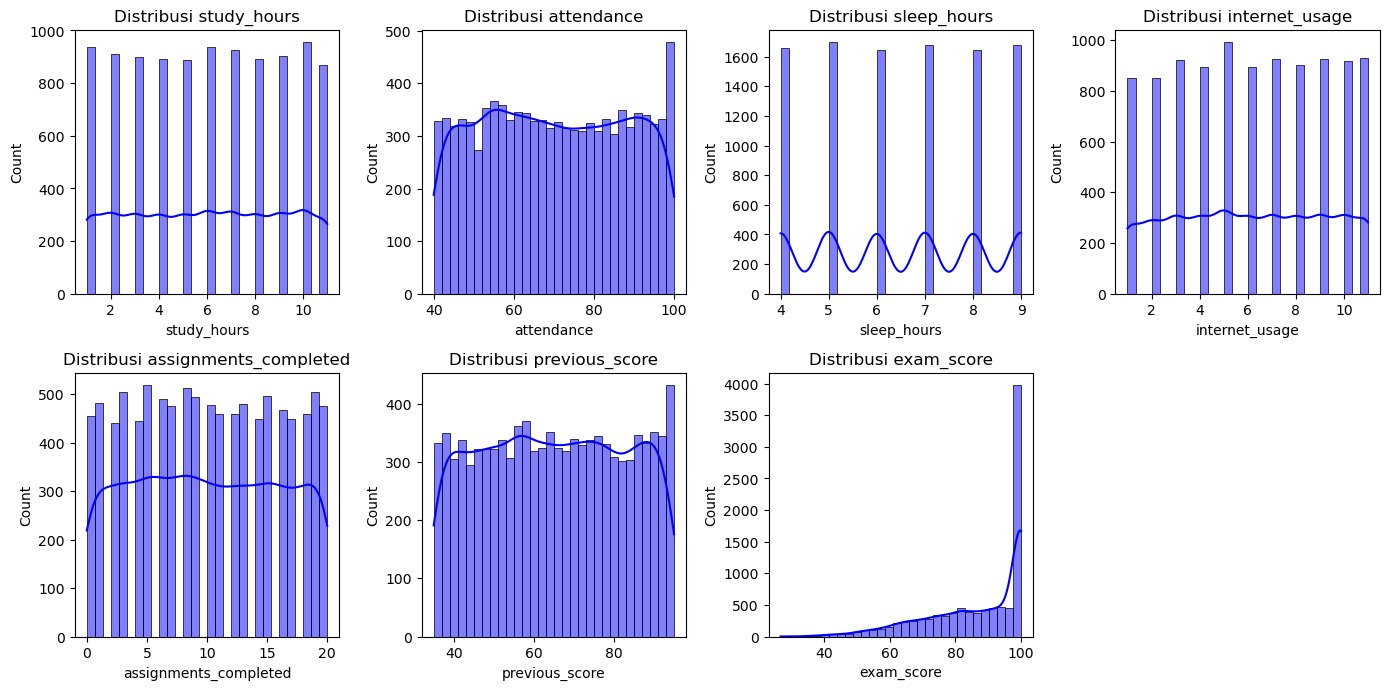

In [8]:
# Distribusi fitur numerik
num_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

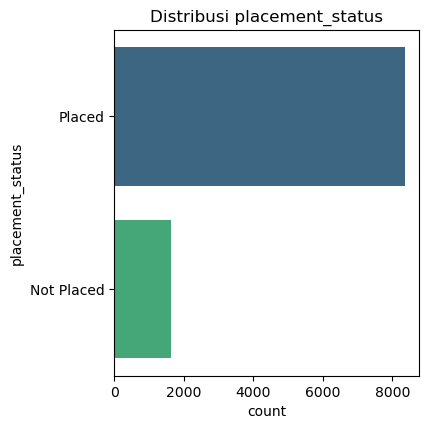

In [9]:
# Distribusi fitur kategorikal
cat_features = df.select_dtypes(include=[object])
plt.figure(figsize=(14, 8))
for i, column in enumerate(cat_features.columns, 1):
	plt.subplot(2, 4, i)
	sns.countplot(y=df[column], hue=df[column], palette='viridis', legend=False)
	plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

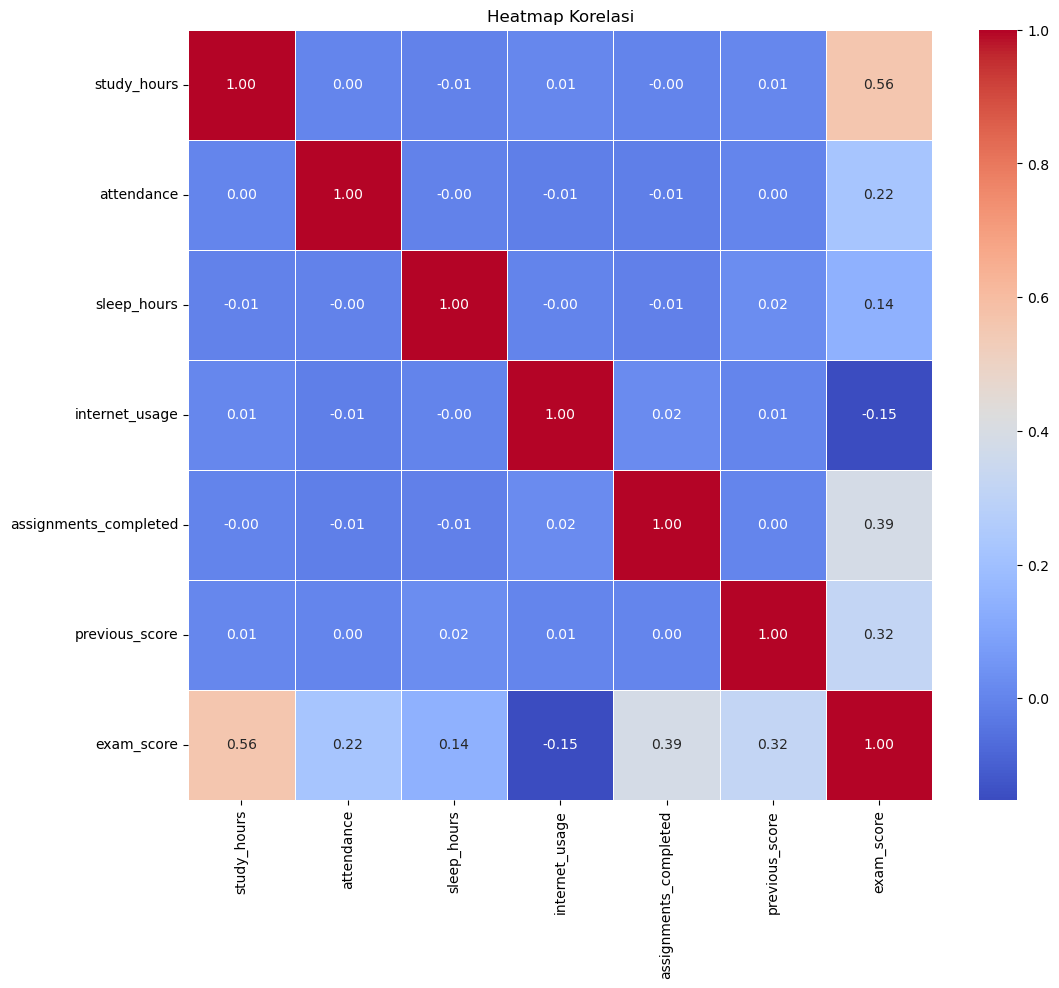

In [10]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

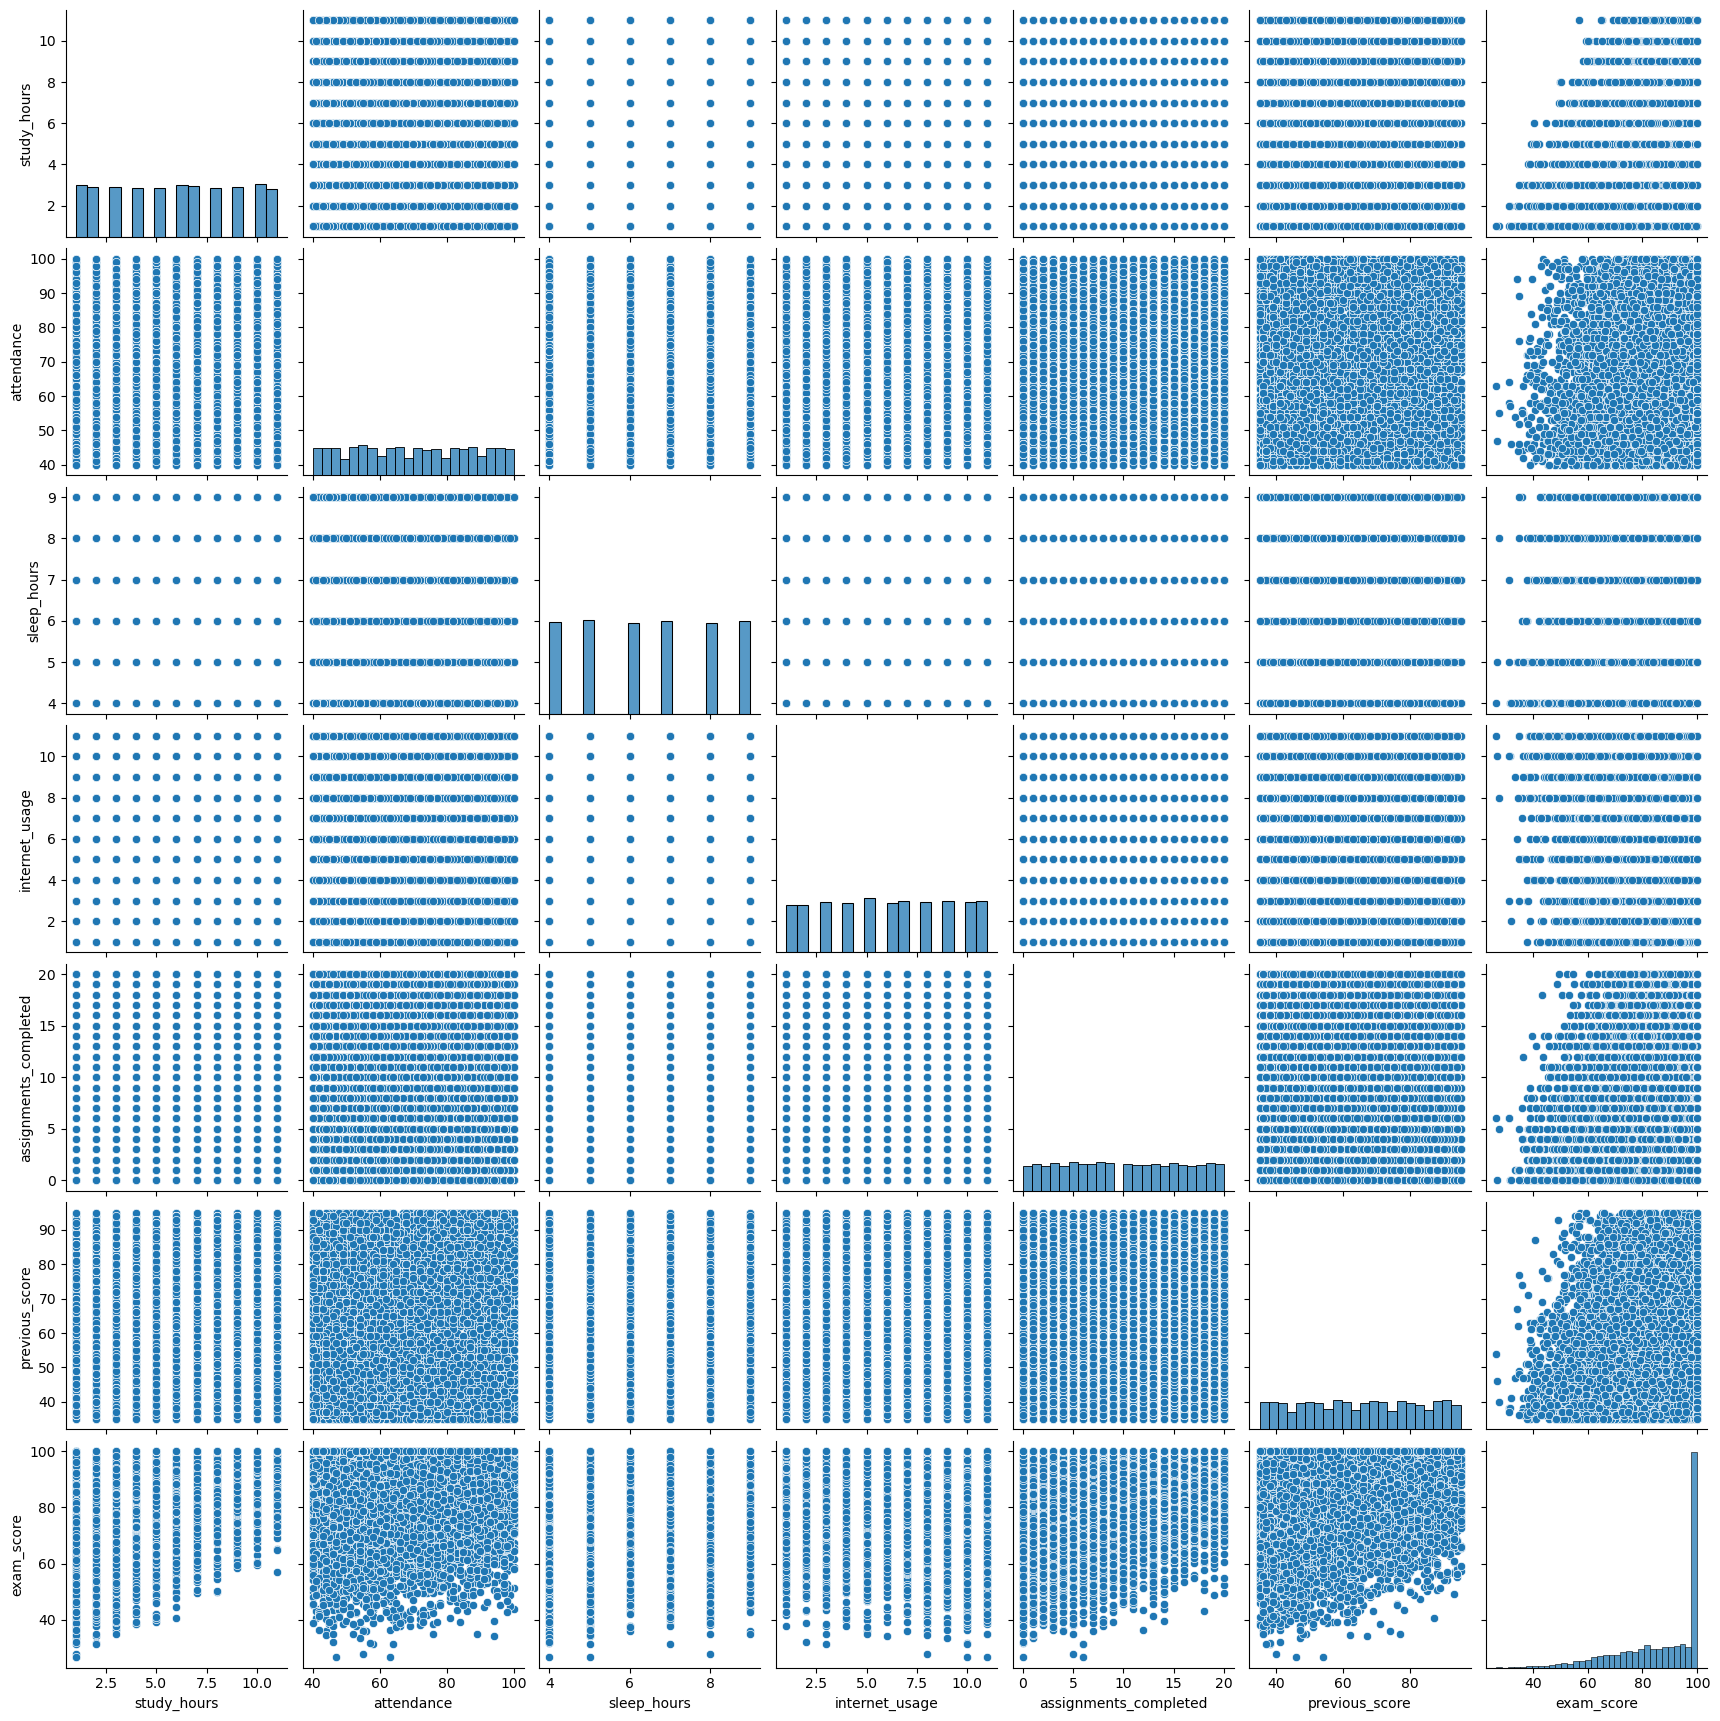

In [11]:
# Pairplot untuk fitur numerik
sns.pairplot(num_features)
plt.show()

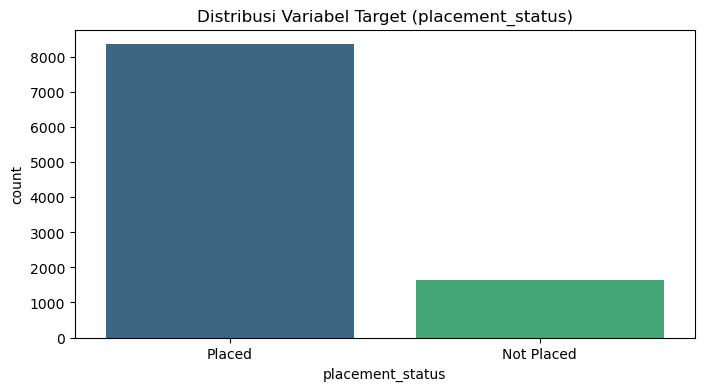

In [12]:
# Visualisasi distribusi variabel target
plt.figure(figsize=(8, 4))
sns.countplot(x=df[column], hue=df[column], palette='viridis', legend=False)
plt.title('Distribusi Variabel Target (placement_status)')
plt.show()

In [13]:
categorical_columns = df.select_dtypes(include=[object]).columns
categorical_columns

Index(['placement_status'], dtype='object')

In [14]:
# Buat instance LabelEncoder
label_encoder = LabelEncoder()

# List kolom kategorikal yang perlu di-encode
categorical_columns = ['placement_status']

# Encode kolom kategorikal
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])
    
# Tampilkan DataFrame untuk memastikan encoding telah diterapkan
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1


In [15]:
# Buat instance MinMaxScaler
scaler = MinMaxScaler()

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['placement_status'])
y = df['placement_status']

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
# Normalisasi semua kolom numerik
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(8000, 7), y_train=(8000,)
Test set shape: X_test=(2000, 7), y_test=(2000,)


In [16]:
# Pelatihan Model dengan penanganan imbalanced data (class_weight='balanced')
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(class_weight='balanced', random_state=42).fit(X_train, y_train)
svm = SVC(class_weight='balanced', random_state=42).fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

print("Model training selesai dengan penyesuaian bobot kelas.")

Model training selesai dengan penyesuaian bobot kelas.


In [17]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results = {
        'Confusion Matrix': cm,
        'True Positive (TP)': tp,
        'False Positive (FP)': fp,
        'False Negative (FN)': fn,
        'True Negative (TN)': tn,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    return results
# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}
# Buat DataFrame untuk meringkas hasil
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
# Isi DataFrame dengan hasil
rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })
# Konversi daftar kamus ke DataFrame
summary_df = pd.DataFrame(rows)
# Tampilkan DataFrame
print(summary_df)

                          Model  Accuracy  Precision    Recall  F1-Score
0     K-Nearest Neighbors (KNN)    0.9515   0.959316  0.983082  0.971053
1            Decision Tree (DT)    1.0000   1.000000  1.000000  1.000000
2            Random Forest (RF)    1.0000   1.000000  1.000000  1.000000
3  Support Vector Machine (SVM)    0.9785   1.000000  0.974018  0.986838
4              Naive Bayes (NB)    0.9715   0.995658  0.969789  0.982553


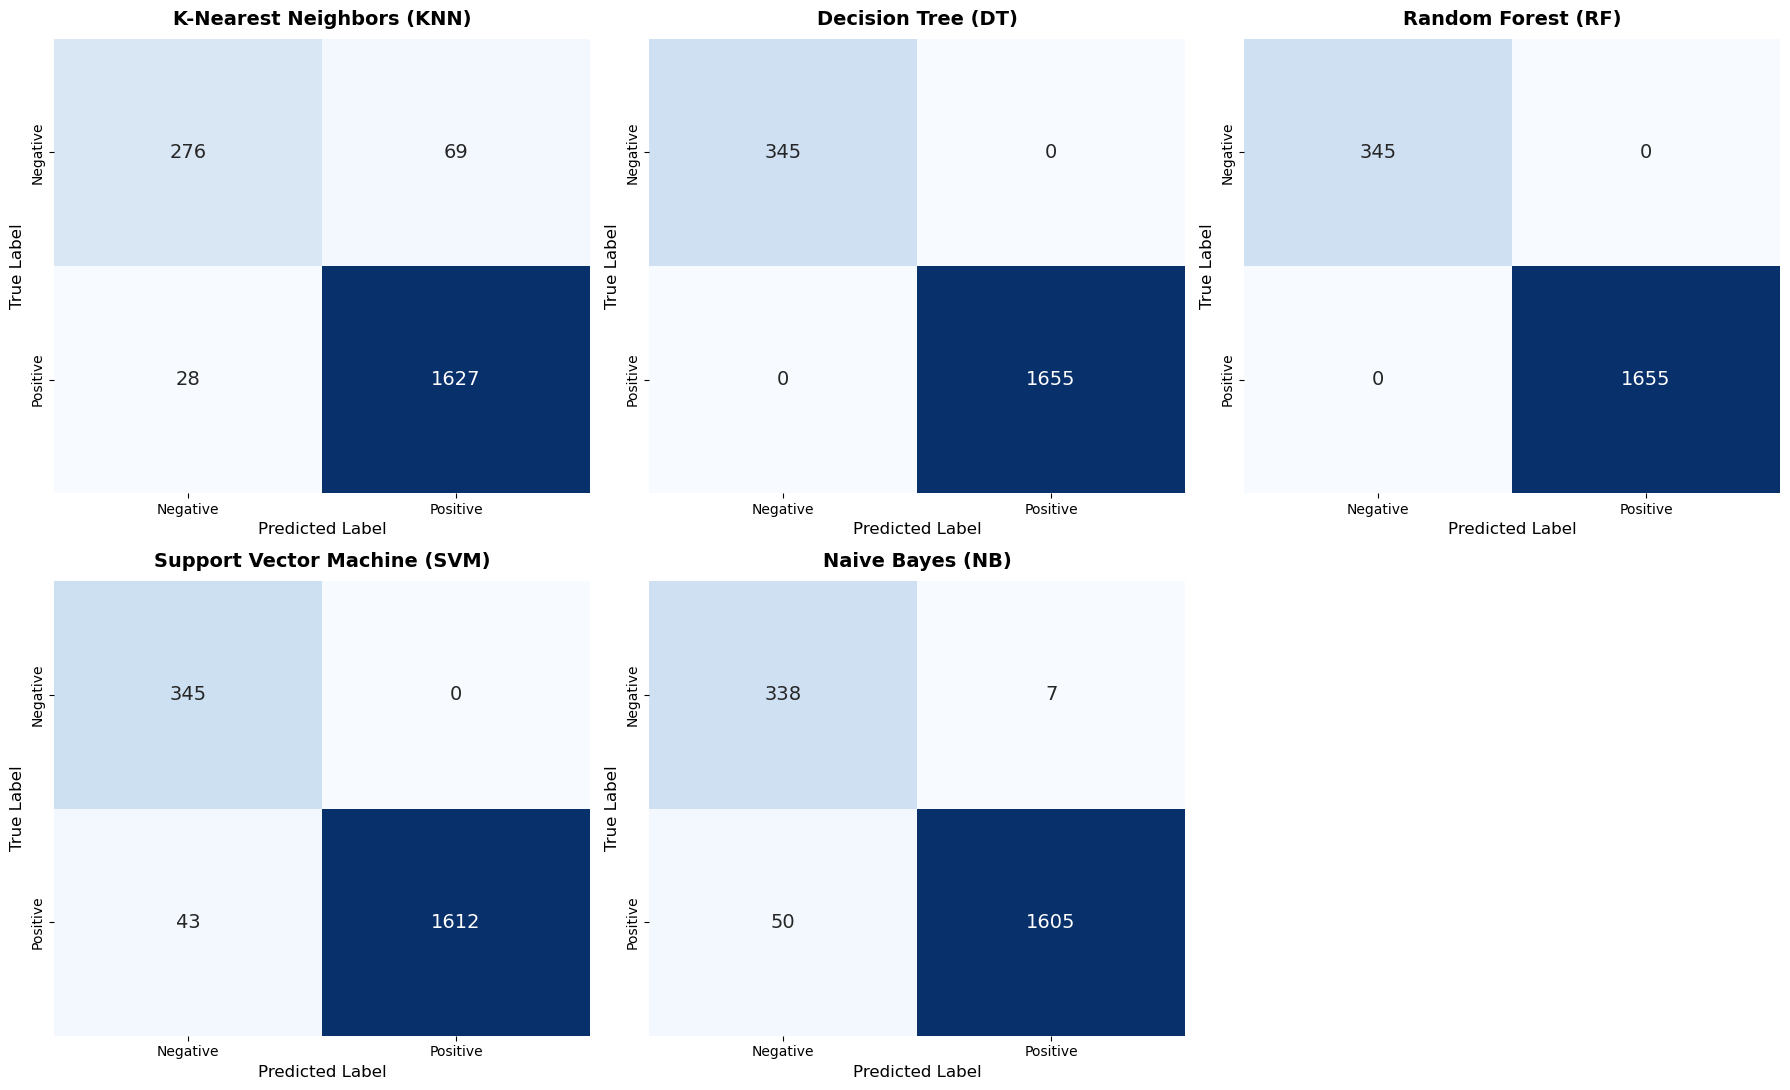

In [18]:
# 1. Membuat grid subplots (2 baris, 3 kolom karena ada 5 model)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()  # Meratakan array axes agar mudah diakses dengan indeks tunggal

# 2. Melakukan perulangan (loop) untuk setiap model di dalam dictionary results
for i, (model_name, metrics) in enumerate(results.items()):
    cm = metrics['Confusion Matrix']
    
    # Membuat heatmap menggunakan seaborn pada objek axes yang bersesuaian
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                cbar=False, annot_kws={"size": 14})
    
    # Mengatur judul dan label untuk masing-masing subplot
    axes[i].set_title(model_name, fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)

# 3. Menghapus subplot ke-6 (indeks ke-5) yang kosong karena kita hanya memiliki 5 model
fig.delaxes(axes[5])

# 4. Menyesuaikan tata letak agar elemen visual tidak saling tumpang tindih
plt.tight_layout()

# 5. Menampilkan grafik visualisasi
plt.show()

# Jika ingin menyimpan gambar grafik, Anda bisa menggunakan perintah di bawah ini:
# plt.savefig('confusion_matrices_comparison.png', dpi=300)